# Capstone Project Part 5: Scenario Analysis and Final Evaluation

### Dataset: UCI Heart Disease Data
https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data/data

**Name:** Takeria Thomas

**Date:** 08/27/2026

**Student ID:** taktho3199


## 1. Setup and Load the Prepared Data

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# set random seeds so the results are reproducible
import os, random
os.environ["PYTHONHASHSEED"] = "42"
np.random.seed(42); random.seed(42); tf.random.set_seed(42)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
import warnings; warnings.filterwarnings("ignore")

2026-08-27 17:53:17.737425: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# load the cleaned dataset created in part 2
data = pd.read_csv("project_cleaned_data.csv")
print("Cleaned dataset shape:", data.shape)
data.head()

Cleaned dataset shape: (920, 17)


,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target,age_group,chol_level
0,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0,55-70,Borderline
1,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1,55-70,High
2,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1,55-70,Borderline
3,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0,<40,High
4,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0,40-55,Borderline


## 2. Rebuild the Part 3 Neural Network

To keep the scenario analysis faithful to Part 3, the same preprocessing pipeline and neural network are recreated here with the same random seed: one-hot encode the categorical predictors, standardize the five continuous predictors (scaler fit on the training split only), and train the two-hidden-layer network.


In [3]:
# separate predictors from target and identify column types
X_raw = data.drop(columns=["target"])
y = data["target"]
numeric_cols = X_raw.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = [c for c in X_raw.columns if c not in numeric_cols]
print("Numeric predictors    :", numeric_cols)
print("Categorical predictors:", categorical_cols)

Numeric predictors    : ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Categorical predictors: ['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'age_group', 'chol_level']


In [4]:
# one-hot encode the categorical predictors (this defines the model's feature columns)
X_encoded = pd.get_dummies(X_raw, columns=categorical_cols, drop_first=True)
bool_cols = X_encoded.select_dtypes(include="bool").columns
X_encoded[bool_cols] = X_encoded[bool_cols].astype(int)
feature_columns = X_encoded.columns.tolist()
print("Total model features:", len(feature_columns))

Total model features: 31


In [5]:
# 80/20 stratified split and standardize numeric predictors (fit on training data only)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = X_train.copy(); X_test = X_test.copy()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols]  = scaler.transform(X_test[numeric_cols])
print("Training shape:", X_train.shape, "| Test shape:", X_test.shape)

Training shape: (736, 31) | Test shape: (184, 31)


In [6]:
# rebuild and train the same two-hidden-layer network used in part 3
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1,  activation="sigmoid")
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, validation_split=0.20,
                    epochs=100, batch_size=16, verbose=0)

# confirm test accuracy matches part 3
test_acc = model.evaluate(X_test, y_test, verbose=0)[1]
print(f"Neural network rebuilt. Test accuracy: {test_acc:.3f}")

2026-08-27 17:53:20.963081: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Neural network rebuilt. Test accuracy: 0.804


**Reusable preprocessing function.** The function below applies the exact same preprocessing to any copy of the cleaned data: it one-hot encodes, re-aligns to the training feature columns, and standardizes the numeric features with the already-fitted scaler. All scenarios are scored through this single function so the pipeline never differs from the trained model's input.


In [7]:
# helper: preprocess any raw copy of the data exactly like the trained network expects
def preprocess(df_raw):
    Xe = pd.get_dummies(df_raw, columns=categorical_cols, drop_first=True)
    Xe = Xe.reindex(columns=feature_columns, fill_value=0)   # align to training columns
    Xe[numeric_cols] = scaler.transform(Xe[numeric_cols])
    return Xe

# helper: summarize the network predictions on a prepared dataset
def summarize(df_raw, name):
    probs = model.predict(preprocess(df_raw), verbose=0).ravel()
    preds = (probs >= 0.5).astype(int)
    return {"Scenario": name,
            "Predicted Positive Rate": round(preds.mean(), 3),
            "Avg Predicted Probability": round(float(probs.mean()), 3)}

## 3. Establish the Baseline Scenario

The baseline runs the trained network on the unmodified cleaned dataset (all 920 patients). No feature values are changed. The summary below the predicted positive rate and the average predicted probability is the reference every scenario is measured against.


In [8]:
# baseline: predict on the unmodified cleaned data
baseline_data = data.drop(columns=["target"]).copy()
baseline = summarize(baseline_data, "Baseline")
print("Baseline predicted positive rate :", baseline["Predicted Positive Rate"])
print("Baseline avg predicted probability:", baseline["Avg Predicted Probability"])

Baseline predicted positive rate : 0.562
Baseline avg predicted probability: 0.556


## 4. Define Three Scenarios

Three realistic what-if scenarios were designed around the features Research Question 3 targets (maximum heart rate, cholesterol, resting blood pressure, and exercise-related variables). Each modifies the cleaned data for every patient, so the analysis asks "if this condition changed across the population, how would the model's predicted risk shift?"

**Scenario 1: Improved Cardiovascular Health**
- Features changed: thalch, oldpeak, exang
- Baseline condition: Original values
- Scenario change: thalch +25 bpm, oldpeak = 0, exang = No
- Why it is relevant: Models a fit patient with a healthy exercise stress test, combining the strongest protective heart-rate and exercise features.

**Scenario 2: Worsened Cholesterol & Blood Pressure**
- Features changed: chol, trestbps
- Baseline condition: Original values
- Scenario change: chol +20%, trestbps +15 mmHg
- Why it is relevant: Models a population whose cholesterol and resting blood pressure drift into unhealthy ranges the classic modifiable risk factors.

**Scenario 3: Exercise Stress Indicators Present**
- Features changed: exang, oldpeak
- Baseline condition: Original values
- Scenario change: exang → True, oldpeak +1.5
- Why it is relevant: Models exercise-induced ischemia (angina on exertion plus greater ST depression); both were among the strongest risk predictors.


## 5. Generate Neural Network Predictions for Each Scenario

In [ ]:
# scenario 1: improved cardiovascular health
s1 = data.drop(columns=["target"]).copy()
s1["thalch"] = s1["thalch"] + 25          # higher achievable peak heart rate (fitness)
s1["oldpeak"] = 0.0                        # no exercise-induced ST depression
s1["exang"] = False                        # no exercise-induced angina
scen1 = summarize(s1, "Scenario 1 - Improved CV Health")
print(scen1)

{'Scenario': 'Scenario 1 - Improved CV Health', 'Predicted Positive Rate': 0.457, 'Avg Predicted Probability': 0.444}


In [ ]:
# scenario 2: worsened cholesterol & blood pressure
s2 = data.drop(columns=["target"]).copy()
s2["chol"] = s2["chol"] * 1.20
s2["trestbps"] = s2["trestbps"] + 15
scen2 = summarize(s2, "Scenario 2 - Worsened Chol & BP")
print(scen2)

{'Scenario': 'Scenario 2 - Worsened Chol & BP', 'Predicted Positive Rate': 0.572, 'Avg Predicted Probability': 0.568}


In [ ]:
# scenario 3: exercise stress indicators present
s3 = data.drop(columns=["target"]).copy()
s3["exang"] = True
s3["oldpeak"] = s3["oldpeak"] + 1.5
scen3 = summarize(s3, "Scenario 3 - Exercise Stress")
print(scen3)

{'Scenario': 'Scenario 3 - Exercise Stress', 'Predicted Positive Rate': 0.664, 'Avg Predicted Probability': 0.661}


## 6. Compare Scenario Results

In [12]:
# build the scenario comparison table
results = pd.DataFrame([baseline, scen1, scen2, scen3])
base_rate = results.loc[0, "Predicted Positive Rate"]
base_prob = results.loc[0, "Avg Predicted Probability"]
results["Rate Diff from Baseline"] = (results["Predicted Positive Rate"] - base_rate).round(3)
results["Prob Diff from Baseline"] = (results["Avg Predicted Probability"] - base_prob).round(3)
results

,Scenario,Predicted Positive Rate,Avg Predicted Probability,Rate Diff from Baseline,Prob Diff from Baseline
0,Baseline,0.562,0.556,0.000,0.000
1,Scenario 1 - Improved CV Health,0.457,0.444,-0.105,-0.112
2,Scenario 2 - Worsened Chol & BP,0.572,0.568,0.010,0.012
3,Scenario 3 - Exercise Stress,0.664,0.661,0.102,0.105


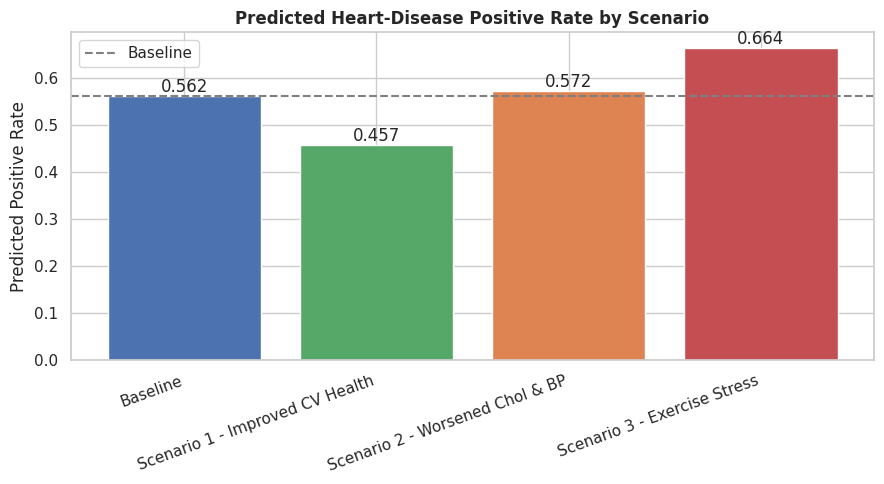

In [13]:
# visualize the predicted positive rate for each scenario
plt.figure(figsize=(9, 5))
colors = ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]
bars = plt.bar(results["Scenario"], results["Predicted Positive Rate"], color=colors)
plt.axhline(base_rate, color="gray", linestyle="--", label="Baseline")
plt.title("Predicted Heart-Disease Positive Rate by Scenario", fontweight="bold")
plt.ylabel("Predicted Positive Rate"); plt.xticks(rotation=20, ha="right")
plt.bar_label(bars, fmt="%.3f"); plt.legend(); plt.tight_layout(); plt.show()

**Analysis of the comparison.**

* **Largest change:** Scenario 1 produced the largest-magnitude shift, lowering the predicted positive rate by about 0.105, and Scenario 3 raised it by almost as much. The two exercise and heart-rate driven scenarios dominate the model's response.
* **Smallest change:** Scenario 2 shifted predictions the least, matching the EDA finding that these two features are only weakly correlated with the outcome on their own.
* **Direction of change:** the directions were exactly as expected healthier inputs lowered predicted risk, while worse risk factors raised it.
* **Relation to the research questions:** this directly answers Research Question 3, changing exercise-related variables and maximum heart rate moves predicted risk far more than changing cholesterol or blood pressure, reinforcing which characteristics matter most.
* **Careful wording:** these results describe how the model's predictions respond to changed inputs. They do not prove that making these changes in a real patient would cause the same change in actual heart-disease risk.


## 7. Scenario Assumptions and Rationale

**Why each scenario was selected.** All three target the features named in Research Question 3 and identified as important in Parts 2 and 3. Scenario 1 probes the strongest protective feature, Scenario 2 probes the classic but weaker modifiable risk factors, and Scenario 3 probes the strongest risk features.

**Why the feature changes are reasonable.** A +25 bpm shift in peak heart rate is a realistic difference between a sedentary and a fitter patient; a 20% cholesterol rise and a 15 mmHg blood-pressure rise fall well within observed clinical ranges; and turning on exercise-induced angina with a 1.5 increase in ST depression represents a plausible move from a normal to an abnormal stress-test result.

**How each relates to the research questions.** Every scenario feeds Research Question 3 and, by ranking which changes matter most, also supports Research Question 1.

**Limitations.** The scenarios are applied uniformly to all patients, which is a simplification. The model reflects correlations in this particular dataset, which is male-skewed and drawn from four hospitals, so the scenario shifts may not generalize. Most importantly, the analysis is a sensitivity test of the model, not evidence of real-world causation.


## 8. Save Scenario Results for the Dashboard

The scenario results are exported to scenario_results.csv for the updated Power BI dashboard.


In [14]:
# export the scenario results for power bi
export = results[["Scenario", "Predicted Positive Rate", "Avg Predicted Probability",
                  "Rate Diff from Baseline", "Prob Diff from Baseline"]].copy()
export.columns = ["Scenario", "PredictedPositiveRate", "AvgPredictedProbability",
                  "RateDiffFromBaseline", "ProbDiffFromBaseline"]
export.to_csv("scenario_results.csv", index=False)
print("Saved: scenario_results.csv")
export

Saved: scenario_results.csv


,Scenario,PredictedPositiveRate,AvgPredictedProbability,RateDiffFromBaseline,ProbDiffFromBaseline
0,Baseline,0.562,0.556,0.000,0.000
1,Scenario 1 - Improved CV Health,0.457,0.444,-0.105,-0.112
2,Scenario 2 - Worsened Chol & BP,0.572,0.568,0.010,0.012
3,Scenario 3 - Exercise Stress,0.664,0.661,0.102,0.105


## 9. Scenario Analysis Findings

* **Baseline:** the network predicted heart disease for a majority of patients on the unmodified data.
* **Scenario 1 (Improved Cardiovascular Health):** predicted risk decreased the most (positive rate from about 0.562 to 0.457), confirming that a healthy exercise stress test and higher peak heart rate are strong protective signals.
* **Scenario 2 (Worse Cholesterol & BP):** predicted risk rose only slightly the smallest change consistent with these being weak standalone predictors.
* **Scenario 3 (Exercise Stress Indicators):** predicted risk increased the most (positive rate to about 0.664), confirming exercise-induced angina and ST depression as the strongest risk signals.
* **Overall conclusion:** the neural network is most sensitive to exercise-related and heart-rate features and least sensitive to cholesterol and blood pressure, which answers Research Question 3 and reinforces the Part 2 / Part 3 finding about which characteristics matter most. These are model-sensitivity results and do not establish real-world causation.
